# Noise Sensitivity Sweep: Electrical Impedance Tomography

- PDE: $-\nabla \cdot (a \nabla u) = 0$
- Latent dimension: $d_a = 6$ (MCMC dimension)
- Observations: Neumann boundary flux at 124 boundary points
- Sweep: SNR $\in \{50, 35, 25, 15\}$ dB and clean baseline

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "snr": n}
    for s, n in itertools.product([42, 123, 7], [None, 50, 35, 25, 15])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.eit import EIT, one_hot_g_l, compute_u_and_grad_eit, mollifier_eit
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_field_comparison, plot_calibration_overlay, plot_noise_sweep,
    plot_std_multi_panel, plot_sweep_summary_table,
    plot_trace, bootstrap_metric_ci,
    plot_eit_ground_truth, plot_eit_observation_data,
    compute_error_std_correlation,
    compute_prior_predictive, build_prior_result,
    tune_sigma, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    load_problem, get_nf_mode, make_log_prior, make_numpyro_model,
    run_map_estimation,
    add_noise_snr_with_sigma,
    sample_unconditional_prior,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results, cross_seed_metric_summary,
)

CHECKPOINT_PATH = Path('../runs/final_eit/weights/best.pt')
TEST_DATA_PATH = '../data/eit/inverse_EIT_in.mat'
TEST_IDX = 0
N_OBS = 124
SNR_LEVELS = [50, 35, 25, 15]
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'
PROBLEM_NAME = 'eit'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = EIT(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_a_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()

print(f"Latent dim (coeff): {d}")
print(f"Latent dim (combined): {problem.BETA_SIZE_U}")

Loading data...


  Test: a=(20, 1024, 1), u=[[[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.8746724 ]
  [ 0.761118  ]
  [ 0.6172527 ]]

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [ 0.3165446 ]
  [ 0.12906456]
  [-0.06325148]]

 [[ 1.        ]
  [ 0.98346853]
  [ 0.9351161 ]
  ...
  [-0.2334332 ]
  [-0.40426344]
  [-0.5620679 ]]

 ...

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [-0.8738502 ]
  [-0.7647962 ]
  [-0.62749803]]

 [[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.10988297]
  [ 0.30528814]
  [ 0.48864248]]

 [[ 1.        ]
  [ 0.9791928 ]
  [ 0.918509  ]
  ...
  [ 0.918509  ]
  [ 0.9791928 ]
  [ 1.        ]]]
  Boundary points: 124 (left=32, top=31, right=31, bottom=30)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 113,702 params


  Initialized u: 83,805 params
  Initialized a: 81,805 params


E0614 15:07:19.379231      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 15,420 params
Loading checkpoint: ../runs/final_eit/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim (coeff): 6
Latent dim (combined): 26


In [4]:
def make_log_likelihood(x_obs_arg, u_obs_arg, normals_arg):
    """Create EIT Neumann likelihood closure."""
    def log_likelihood_fn(beta_a, sigma):
        beta_b = beta_a[None, :]
        g_l_onehot = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot], axis=-1)

        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'],
            x_obs_arg[0], beta_u[0], g_l_scalar
        )

        a_vals = problem.models['a'].apply(
            {'params': params['a']}, x_obs_arg, beta_b
        )[0]

        neumann_pred = a_vals * (du_vals[:, 0] * normals_arg[:, 0] + du_vals[:, 1] * normals_arg[:, 1])
        neumann_obs = u_obs_arg[0, :, 0]

        sq_err = jnp.sum((neumann_pred - neumann_obs) ** 2)
        n = neumann_obs.shape[0]
        return -0.5 * sq_err / (sigma ** 2) - 0.5 * n * jnp.log(2 * jnp.pi * sigma ** 2)
    return log_likelihood_fn

## 2. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=100.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.25),
)

## 3. Per-Seed Loop


######################################################################
# SEED = 7
######################################################################



x_obs (boundary): (1, 124, 2), u_obs (Neumann flux): (1, 124, 1)
Boundary points: 124, g_l = 1


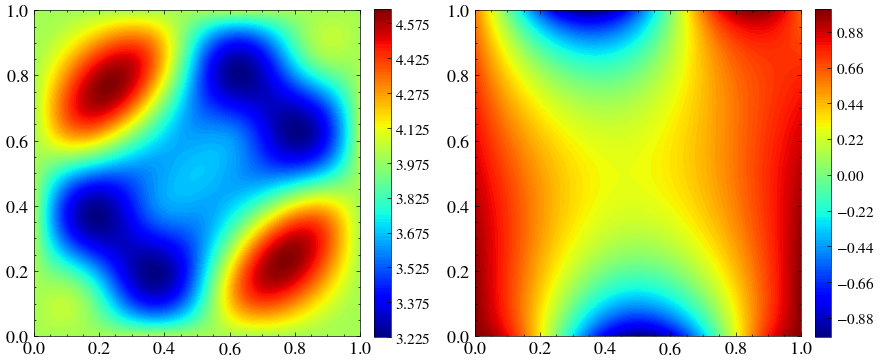

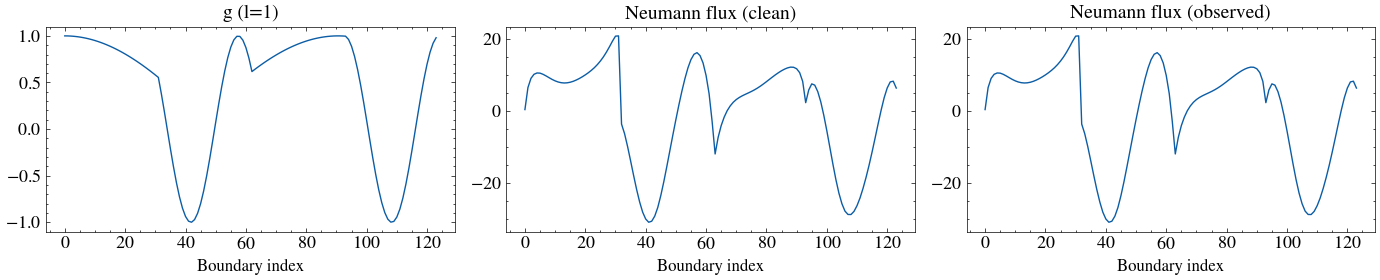

Prior predictive: a_err=0.3371, CRPS=0.8400, cov95=1.0000
  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=100.0, target=neumann


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

Inverting:   0%|          | 1/200 [00:03<12:59,  3.92s/it]

Inverting:  40%|████      | 81/200 [00:04<00:04, 28.38it/s]

...

sample: 100%|█████████▉| 1993/2000 [00:43<00:00, 44.11it/s]

sample: 100%|█████████▉| 1998/2000 [00:43<00:00, 45.06it/s]

sample: 100%|██████████| 2000/2000 [00:43<00:00, 45.92it/s]

MCMC warmup: 153.1s, sampling: 43.6s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
 beta_a[0]     -0.67      0.02     -0.67     -0.70     -0.65   3625.83      1.00
 beta_a[1]      0.10      0.02      0.09      0.06      0.13   5860.30      1.00
 beta_a[2]     -0.73      0.02     -0.73     -0.77     -0.69   5344.72      1.00
 beta_a[3]      0.83      0.02      0.84      0.80      0.87   2691.78      1.00
 beta_a[4]      0.04      0.02      0.04      0.01      0.08   5308.75      1.00
 beta_a[5]      0.18      0.02      0.17      0.14      0.21   3268.92      1.00

Number of divergences: 14
ESS min=2691.8, R-hat max=1.0017, divergences=14/8000, [PASS] All diagnostics within thresholds


  Chi2 PPC: chi2=107.18, p=0.8594 (df=124)
Saved structured result to: /workspace/experiments/results/structured/noise_sweep/eit_2026-06-14T15-24-53_seed7.json

  EIT — Noise Sensitivity
  Condition                  CRPS(a)    Coverage    CI Width   Sharpness   Rel.L2(a)     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  Clean                     0.107830     89.84%     0.719987    0.183215    0.052698          14      2691.8      1.0017    PASS



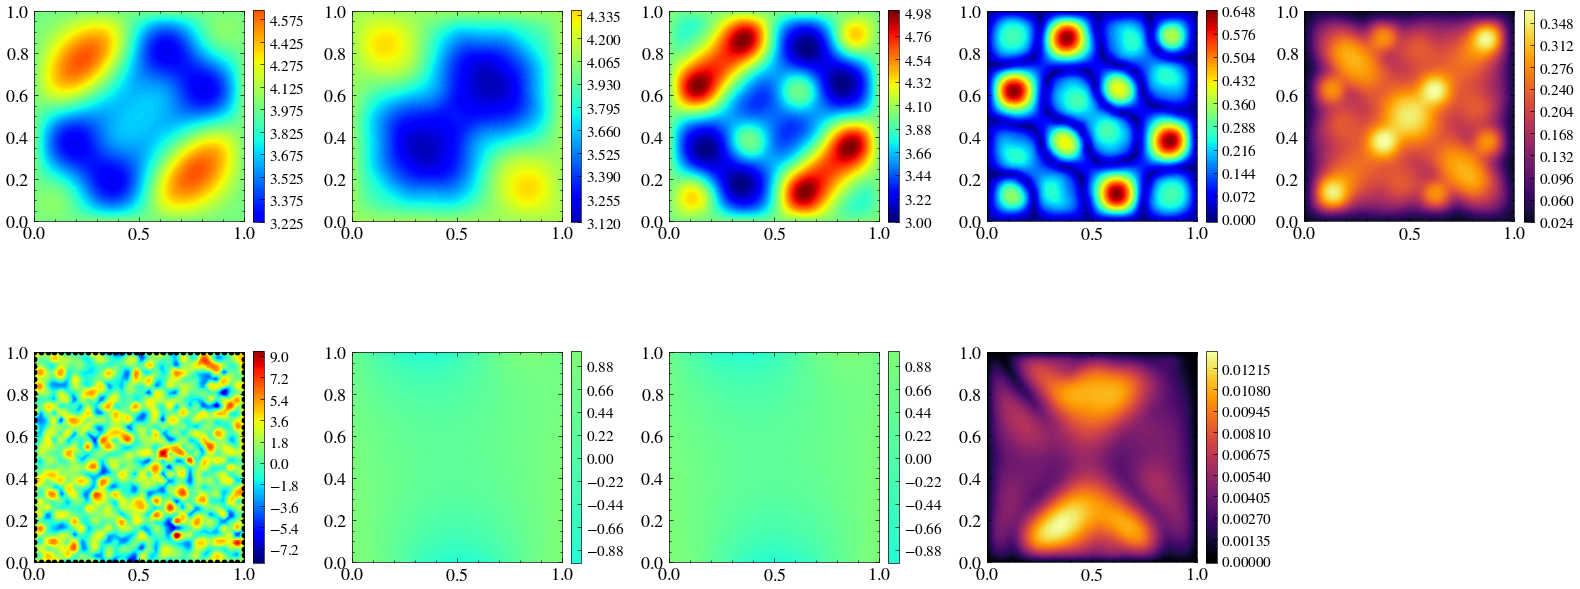


Bootstrap CIs on CRPS(a) at each condition:
         label      CRPS              95% CI


      SNR=15dB  0.10783  [0.10688, 0.10888]

SNR=15dB (sigma=2.481278):
  ESS: min=2691.8, mean=4350.0
  R-hat: max=1.0017, mean=1.0007
  Divergences: 14 / 8000
   dim       ESS     R-hat        mean         std
     0    3625.8    1.0011     -0.6720      0.0167
     1    5860.3    0.9998      0.0950      0.0195
     2    5344.7    1.0002     -0.7287      0.0216
     3    2691.8    1.0017      0.8343      0.0230
     4    5308.7    1.0004      0.0447      0.0237
     5    3268.9    1.0010      0.1763      0.0218


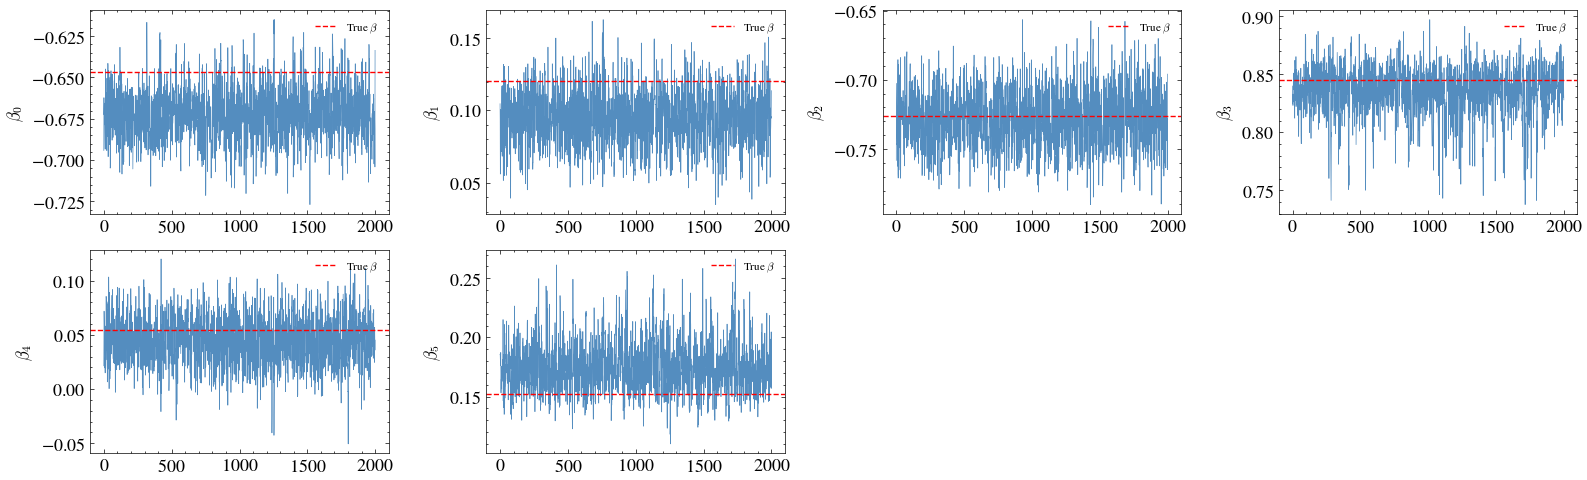

In [6]:
from results_schema import ExperimentResult
from datetime import datetime
from src.utils.PlotFigure import Plot

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}\n")

    FIGURE_DIR = Path(f'figures/noise_sweep_{PROBLEM_NAME}/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)
    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs_clean = obs_data['u_obs']  # Neumann flux
    a_true = obs_data['a_true']
    g_l = obs_data['g_l']
    u_true = obs_data.get('u_true', None)

    n_bd = x_obs.shape[1]
    normals = problem._active_boundary_normals_jax

    print(f"x_obs (boundary): {x_obs.shape}, u_obs (Neumann flux): {u_obs_clean.shape}")
    print(f"Boundary points: {n_bd}, g_l = {int(g_l[0, 0])}")

    plot_eit_ground_truth(
        np.array(x_full[0]),
        np.array(a_true[0, :, 0]),
        u_true=np.array(u_true[0, :, 0]) if u_true is not None else None,
        save_path=FIGURE_DIR / 'ground_truth.png',
    )

    plot_eit_observation_data(
        x_bd=np.array(x_obs[0]),
        g_l=int(g_l[0, 0]),
        neumann_obs=np.array(u_obs_clean[0, :, 0]),
        save_path=FIGURE_DIR / 'observation_data.png',
    )

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ### MAP Baseline
    map_result = run_map_estimation(problem, params, x_obs, u_obs_clean, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = float(rmse(a_map, a_true[0]))
    print(f"MAP RMSE (a): {rmse_map_a:.6f}")

    # ### Sigma Tuning
    log_lik_clean = make_log_likelihood(x_obs, u_obs_clean, normals)
    numpyro_model_clean = make_numpyro_model(d, log_prior_fn, log_lik_clean, sample_name="beta_a")

    def _model_factory(sigma):
        def _model():
            numpyro_model_clean(sigma=sigma)
        return _model

    x_full_tiled = jnp.tile(x_full, (1, 1, 1))

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            a_pred = problem.models['a'].apply({'params': params['a']}, x_full_tiled, jnp.array(beta_i))
            a_preds.append(np.array(a_pred[0]))
        return np.stack(a_preds)

    rng, tune_key = jax.random.split(rng)
    sigma_tuned, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_a_mode,
        sigma_candidates=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
        sample_name='beta_a',
    )
    print(f"sigma (tuned): {sigma_tuned:.6f}")

    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (×{inv_config.loss_weights.pde})', f'Data (×{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### EIT-specific decode
    def decode_posterior(beta_a_samples, batch_size=200):
        n_s = beta_a_samples.shape[0]
        g_l_onehot = one_hot_g_l(problem._current_g_l)
        a_preds, u_preds = [], []

        for i in range(0, n_s, batch_size):
            batch_beta = beta_a_samples[i:i + batch_size]
            n_b = batch_beta.shape[0]
            x_tile = jnp.tile(x_full, (n_b, 1, 1))

            a_b = problem.models['a'].apply({'params': params['a']}, x_tile, batch_beta)
            a_b = a_b[..., None] if a_b.ndim == 2 else a_b
            a_preds.append(a_b)

            g_l_onehot_tiled = jnp.tile(g_l_onehot, (n_b, 1))
            beta_u = jnp.concatenate([batch_beta, g_l_onehot_tiled], axis=-1)
            u_b = problem.models['u'].apply({'params': params['u']}, x_tile, beta_u)
            u_b = u_b[..., None] if u_b.ndim == 2 else u_b
            g_l_tiled = jnp.tile(problem._current_g_l, (n_b, 1))
            u_b = mollifier_eit(u_b.squeeze(-1), x_tile, g_l_tiled)
            u_preds.append(u_b)

        a_pred = jnp.concatenate(a_preds, axis=0)   # (n_s, n_mesh, 1)
        u_pred = jnp.concatenate(u_preds, axis=0)   # (n_s, n_mesh)

        return a_pred, u_pred

    # ### Run conditions
    def run_condition(snr_db, rng_key):
        rng_key, noise_key, mcmc_key = random.split(rng_key, 3)

        if snr_db is not None:
            u_obs_noisy, noise_sigma = add_noise_snr_with_sigma(u_obs_clean, snr_db, noise_key)
            label = f"SNR={snr_db}dB"
            print(f"\n{'='*60}\n  {label} (noise_sigma={noise_sigma:.6f})\n{'='*60}")
        else:
            u_obs_noisy = u_obs_clean
            noise_sigma = None
            label = "Clean"
            print(f"\n{'='*60}\n  {label}\n{'='*60}")

        sigma = max(noise_sigma if noise_sigma is not None else 0.0, sigma_tuned)

        log_lik_fn = make_log_likelihood(x_obs, u_obs_noisy, normals)
        numpyro_model = make_numpyro_model(d, log_prior_fn, log_lik_fn, sample_name="beta_a")

        nuts_cfg = recommended_nuts_config(d, sigma)
        print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
              f"max_tree_depth={nuts_cfg['max_tree_depth']}")

        mcmc, timing = run_mcmc(
            numpyro_model, {"beta_a": beta_a_mode}, {"sigma": sigma}, mcmc_key,
            NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
        )
        mcmc.print_summary(exclude_deterministic=True)

        diag = extract_mcmc_diagnostics(mcmc, sample_name="beta_a", total_samples=NUM_CHAINS * NUM_SAMPLES)
        beta_a_samples = diag['samples']

        a_pred, u_pred = decode_posterior(beta_a_samples)
        a_np = np.array(a_pred[:, :, 0])

        metrics = compute_standard_metrics(a_np, a_true_np)

        spearman_rho, spearman_p = compute_error_std_correlation(
            a_true_np, np.mean(a_np, axis=0), np.std(a_np, axis=0),
        )

        # Chi-squared PPC (EIT: uses Neumann flux predictions)
        g_l_scalar = problem._current_g_l[0, 0]

        def compute_neumann_for_beta(beta_a_single):
            beta_b = beta_a_single[None, :]
            g_l_onehot_s = one_hot_g_l(jnp.array([[g_l_scalar]], dtype=jnp.float32))
            beta_u = jnp.concatenate([beta_b, g_l_onehot_s], axis=-1)
            _, du_vals = compute_u_and_grad_eit(
                params['u'], problem.models['u'], x_obs[0], beta_u[0], g_l_scalar
            )
            a_vals = problem.models['a'].apply({'params': params['a']}, x_obs, beta_b)[0]
            a_vals = a_vals.squeeze(-1) if a_vals.ndim == 2 else a_vals
            return a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])

        n_pred = min(100, beta_a_samples.shape[0])
        pred_idx = np.linspace(0, beta_a_samples.shape[0] - 1, n_pred, dtype=int)
        flux_pred = np.stack(
            [np.array(compute_neumann_for_beta(beta_a_samples[idx])) for idx in pred_idx], axis=0
        )
        neumann_obs_np = np.array(u_obs_noisy[0, :, 0])
        chi2_stat, chi2_pval = chi2_ppc(neumann_obs_np, flux_pred, sigma)
        print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={neumann_obs_np.shape[0]})")

        return {
            'label': label, 'snr_db': snr_db,
            'noise_sigma': noise_sigma, 'sigma': sigma,
            'beta_samples': np.array(beta_a_samples),
            'beta_by_chain': diag['by_chain'],
            'beta_for_trace': diag['by_chain'][0],
            'a_pred': a_pred, 'u_pred': u_pred,
            'a_mean': np.array(jnp.mean(a_pred, axis=0)[:, 0]),
            'a_std': np.array(jnp.std(a_pred, axis=0)[:, 0]),
            'u_mean': np.array(jnp.mean(u_pred, axis=0)),
            'u_std': np.array(jnp.std(u_pred, axis=0)),
            'ess_min': diag['ess_min'],
            'rhat_max': diag['rhat_max'],
            'rhat_mean': diag['rhat_mean'],
            'n_div': diag['n_div'],
            'reliability_flag': diag['flag'],
            'chi2_ppc': chi2_stat,
            'chi2_ppc_pvalue': chi2_pval,
            'spearman_rho_error_std': spearman_rho,
            'spearman_pvalue_error_std': spearman_p,
            'warmup_time_s': timing['warmup_time_s'],
            'sampling_time_s': timing['sampling_time_s'],
            'step_time_s': timing['step_time_s'],
            **metrics,
        }

    if _task_id is not None:
        _snr_iter = [PARAMETER_GRID[_task_id]["snr"]]
    else:
        _snr_iter = [None] + SNR_LEVELS

    all_results = []
    for snr_db in _snr_iter:
        rng, key = random.split(rng)
        res = run_condition(snr_db, key)
        if snr_db is None:
            res['map_a_err'] = rmse_map_a
        all_results.append(res)

    res_clean = next((r for r in all_results if r['snr_db'] is None), None)
    sweep_results = [r for r in all_results if r['snr_db'] is not None]

    def _to_mcmc_result(res):
        return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="noise_sweep",
        problem="eit",
        experiment_type="sweep",
        sweep_var="snr_db",
        seed=SEED,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        prior=build_prior_result(prior_metrics),
        baseline=_to_mcmc_result(res_clean) if res_clean is not None else None,
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    x_np = np.array(x_full[0])
    all_for_plot = ([res_clean] if res_clean is not None else []) + sweep_results
    all_labels = ['Clean'] + [f'SNR={s}dB' for s in SNR_LEVELS]
    plot_sweep_summary_table(all_for_plot, all_labels, title='EIT — Noise Sensitivity')

    preds_map_cond = problem.predict_from_beta(params, beta_map, x_full)
    u_map = preds_map_cond['u_pred'][0]

    for res in all_for_plot:
        if u_true is not None:
            if res['noise_sigma'] is not None:
                key_viz = random.PRNGKey(int(res['snr_db']))
                u_display = np.array((u_true + random.normal(key_viz, u_true.shape) * res['noise_sigma'])[0, :, 0])
            else:
                u_display = np.array(u_true[0, :, 0])

        fc_kwargs = dict(
            x=x_np,
            a_true=a_true_np,
            a_map=np.array(a_map[:, 0]),
            a_mean=res['a_mean'],
            a_std=res['a_std'],
            grid_shape=(32, 32),
            obs_coords=np.array(x_obs[0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["label"].replace("=", "").replace(" ", "_").lower()}.png',
        )
        if u_true is not None:
            fc_kwargs.update(
                u_true=u_display,
                u_map=np.array(u_map[:, 0]),
                u_mean=res['u_mean'],
                u_std=res['u_std'],
            )
        plot_field_comparison(**fc_kwargs)

    if res_clean is not None:
        plot_noise_sweep(sweep_results, baseline=res_clean, save_path=FIGURE_DIR / 'noise_sweep.png')

        stds = [res_clean['a_std']]
        labels_std = ['Clean']
        for res in sweep_results:
            stds.append(res['a_std'])
            labels_std.append(res['label'])

        plot_std_multi_panel(
            x_np, stds, labels_std, grid_shape=(32, 32),
            suptitle='Posterior Std: Noise Sensitivity (EIT)',
            save_path=FIGURE_DIR / 'std_multi_panel.png',
        )

        cal_list = [(res_clean['cal_levels'], res_clean['cal_empirical'], 'Clean')]
        for res in sweep_results:
            cal_list.append((res['cal_levels'], res['cal_empirical'], res['label']))
        plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

        with plt.style.context(['default']):
            fig, ax = plt.subplots(figsize=(6, 4))
            snrs = [r['snr_db'] for r in sweep_results]
            widths = [r['ci_width'] for r in sweep_results]
            ax.plot(snrs, widths, 'o-', color='C0', label='Noisy')
            ax.axhline(res_clean['ci_width'], ls='--', color='grey', label='Clean baseline')
            ax.set_xlabel('SNR (dB)')
            ax.set_ylabel('Mean 95% CI Width')
            ax.set_title('CI Width vs Observation Noise (EIT)')
            ax.invert_xaxis()
            ax.legend()
            plt.tight_layout()
            fig.savefig(FIGURE_DIR / 'ci_width_vs_noise.png', dpi=200, bbox_inches='tight')
            plt.show()

    # Statistical Trend Analysis
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(4)
    print("\nBootstrap CIs on CRPS(a) at each condition:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'95% CI':>18s}")
    for res in all_for_plot:
        a_np = np.array(res['a_pred'])[:, :, 0] if np.array(res['a_pred']).ndim == 3 else np.array(res['a_pred'])
        a_t = a_true_np
        ci = bootstrap_metric_ci(a_np, a_t, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    # Diagnostics
    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)

    for res in all_for_plot:
        beta_by_chain = res['beta_by_chain']
        from numpyro.diagnostics import effective_sample_size, split_gelman_rubin
        ess = effective_sample_size(beta_by_chain)
        rhat = split_gelman_rubin(beta_by_chain)
        print(f"\n{res['label']} (sigma={res['sigma']:.6f}):")
        print(f"  ESS: min={float(ess.min()):.1f}, mean={float(ess.mean()):.1f}")
        print(f"  R-hat: max={float(rhat.max()):.4f}, mean={float(rhat.mean()):.4f}")
        print(f"  Divergences: {res['n_div']} / {NUM_SAMPLES * NUM_CHAINS}")

        print(f"  {'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
        for i in range(d):
            beta_all = res['beta_samples']
            print(f"  {i:4d}  {float(ess[i]):8.1f}  {float(rhat[i]):8.4f}  "
                  f"{float(beta_all[:, i].mean()):10.4f}  "
                  f"{float(beta_all[:, i].std()):10.4f}")

        plot_trace(res['beta_for_trace'], beta_true_np, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_{res["label"].replace("=", "").replace(" ", "_").lower()}.png')

## Cross-Seed Aggregation Summary

In [7]:
results = load_cross_seed_results("noise_sweep", "eit")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    if results[0].baseline is not None:
        print("=== Baseline (Clean) ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            try:
                s = cross_seed_metric_summary(results, metric=m)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (45 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123])

=== Baseline (Clean) ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0054      0.0008      0.0044      0.0059
crps_a                0.0123      0.0016      0.0102      0.0135
nll_a                -2.3913      0.1225     -2.5546     -2.3058
coverage_95           0.9915      0.0039      0.9863      0.9941
ci_width              0.1190      0.0164      0.0972      0.1310
mean_std              0.0303      0.0041      0.0248      0.0334
ess_min            2362.5438   1128.6904    955.5635   3528.5207
rhat_max              1.0027      0.0016      1.0009      1.0046
n_div                11.0000      6.7639      6.0000     20.0000
